In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import os
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import zeus

from scipy.interpolate import PchipInterpolator, CubicSpline

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
config = toml.load(f"{home_dir}/alfred/scripts/config_files/mcmc_config.toml")
config = SimpleNamespace(**config)

In [4]:
rundirs = ['productionruns2_mechaemu',
                            'productionruns3_mechaemu_fiducialtau', 
                            'productionruns3_mechaemu_simu10818']
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']


chains_runs = []
for dir in rundirs:
    chains_surveys = []
    for survey in survey_labels:
        chains = []
        for setup in setups:
            path = f"{base_dir}/inference/{dir}/{survey}/{setup}"
            if os.path.exists(f"{path}/saved_chains.h5"):
                s, l = utils.load_samples(path)
                chains.append(s)

        chains_surveys.append(chains)
    chains_runs.append(chains_surveys)

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/noiseless_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/noiseless...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/noiseless_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/SO-LAT/noiseless...
Load

In [59]:
chains = [chains_runs[0][0][1], chains_runs[1][0][1]]
len(chains)

2

In [56]:
rundirs = ['productionruns2_mechaemu',
                            'productionruns3_mechaemu_fiducialtau', 
                            'productionruns3_mechaemu_simu10818']
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

chains_surveys = []
for survey in survey_labels:
    chains = []
    for dir in rundirs[:2]:
        for setup in setups[2:]:
            path = f"{base_dir}/inference/{dir}/{survey}/{setup}"
            if os.path.exists(f"{path}/saved_chains.h5"):
                s, l = utils.load_samples(path)
                chains.append(s)

    chains_surveys.append(chains)


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-HD/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_fiducialtau/CMB-HD/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_fiducialtau/CMB-HD/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns2_mechaemu/CMB-S4/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_fiducialtau/CMB-S4/addnoise...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_fiducialtau/CMB-S4/addnoise_Planck...
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/produ

In [12]:
true_params = [*df.loc[config.sn].to_numpy(), *whatthetau(df.loc[config.sn].to_numpy())]
true_params

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


[np.float64(-1.7166987712964503),
 np.float64(0.0),
 np.float64(3.277127671229863),
 np.float64(8.53),
 np.float64(0.275),
 np.float64(0.05526446348700878)]

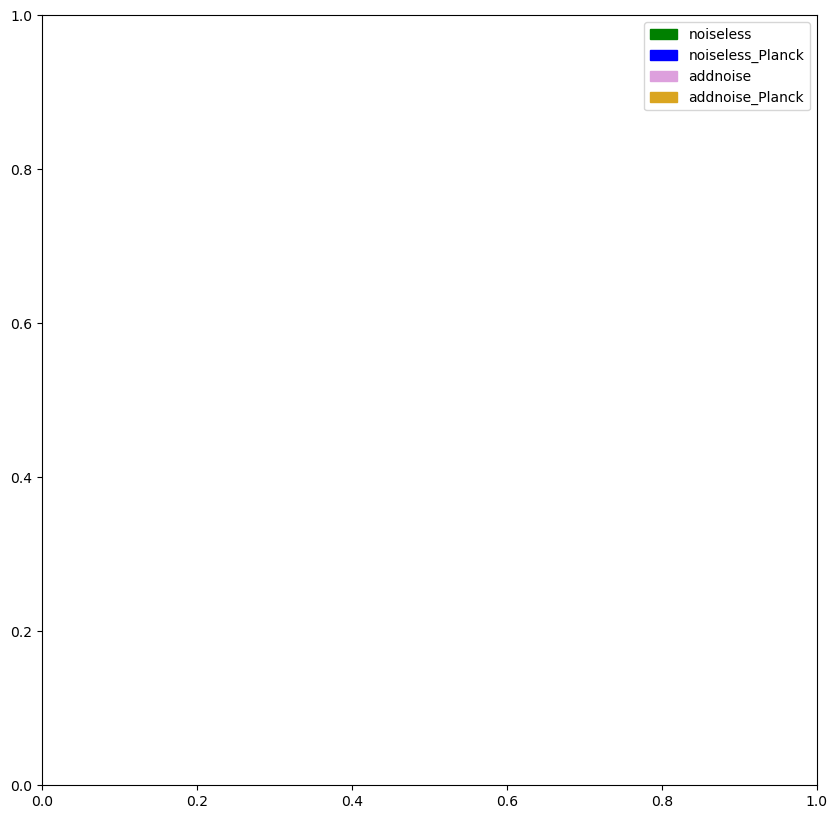

In [13]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

In [117]:
s, l = utils.load_samples(f'{base_dir}/inference/productionruns_justpriors/CMB-HD')

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns_justpriors/CMB-HD...


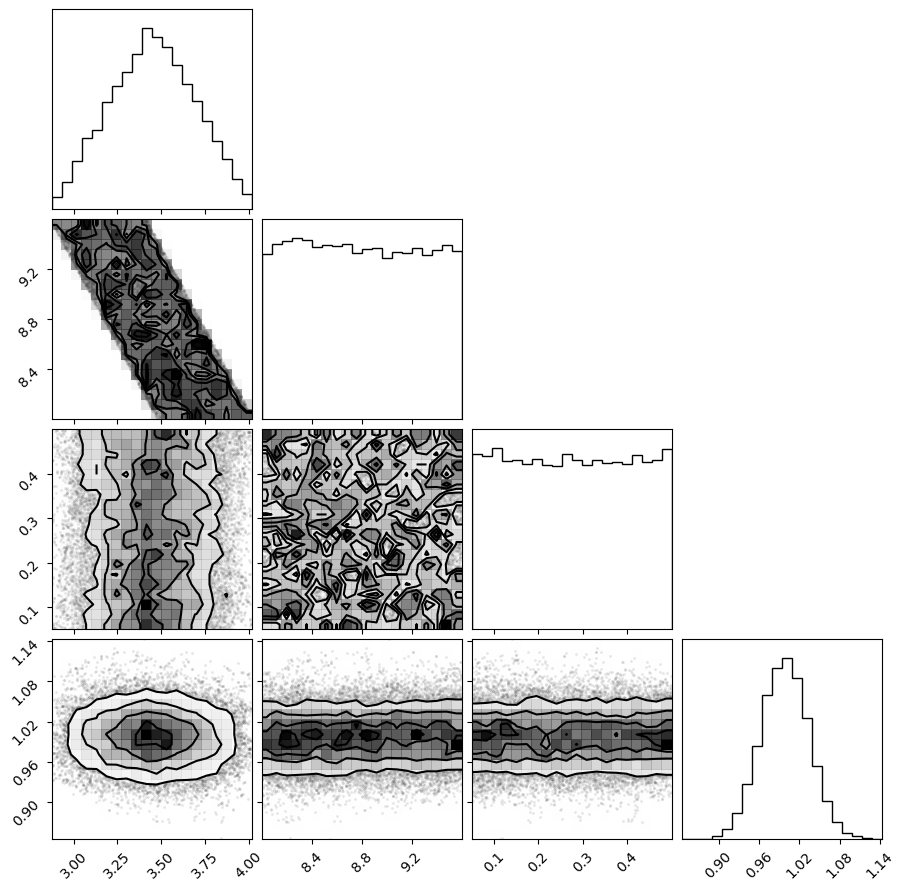

In [118]:
fig = corner.corner(s)

run_i=0
survey_i=0


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


survey_i=1
run_i=1
survey_i=0


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


survey_i=1
run_i=2
survey_i=0


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


survey_i=1


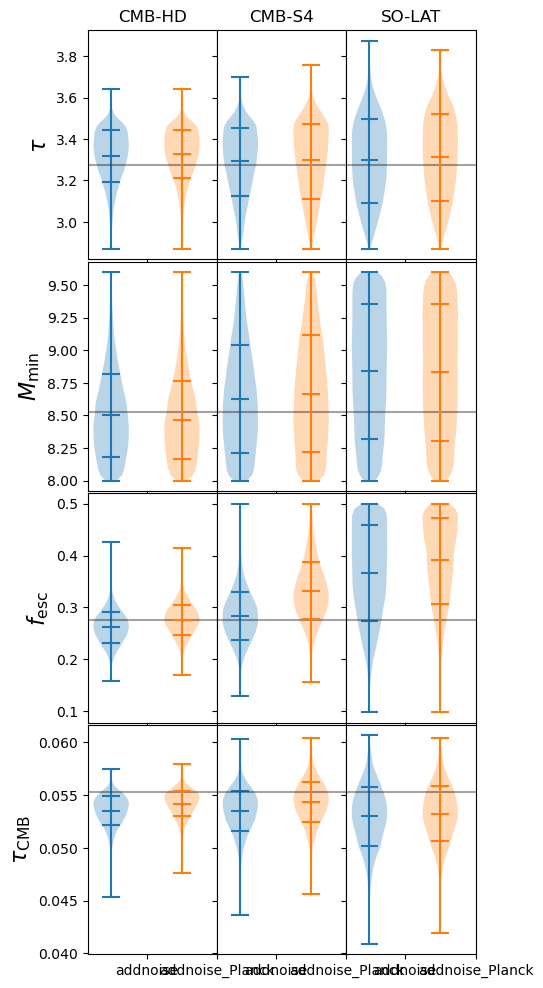

In [95]:
fig, ax = plt.subplots(4, len(survey_labels)+1, sharex=True, sharey='row', figsize=(5,12))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

for run_i, survey_chains in enumerate(chains_runs[0]):
    print(f"run_i={run_i}")
    for survey_i, chain in enumerate(survey_chains[2:]):
        print(f"survey_i={survey_i}")
    # lp = lps[n]
    # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin
        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True
        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())
  
        for ip, p in enumerate(true_params[2:]):
            ax[ip,run_i].axhline(p, alpha=.2, color='black')
            ax[ip,run_i].violinplot(chain[:,ip], [survey_i+.5], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            if ip == len(true_params[2:]) -1:
                ax[ip,0].set_ylabel(rf"$\tau_{{\mathrm{{CMB}}}}$", fontsize=16)
            else:
                ax[ip,0].set_ylabel(astro_pnames_formatted[2+ip], fontsize=16)
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,run_i].set_xticks(np.arange(1, len(setups[2:])+.5))
    ax[3,i].set_xticklabels([f"{setup}" for si, setup in enumerate(setups[2:])])

    ax[0,run_i].set_title(f'{survey_labels[run_i]}', fontsize=12)

    #ax[0,run_i].set_title(f'priors', fontsize=12)

    fig.savefig('violins.png', bbox_inches='tight', pad_inches=0.05, dpi=300)


run_i=0
survey_i=0
survey_i=1
run_i=1
survey_i=0
survey_i=1
run_i=2
survey_i=0
survey_i=1


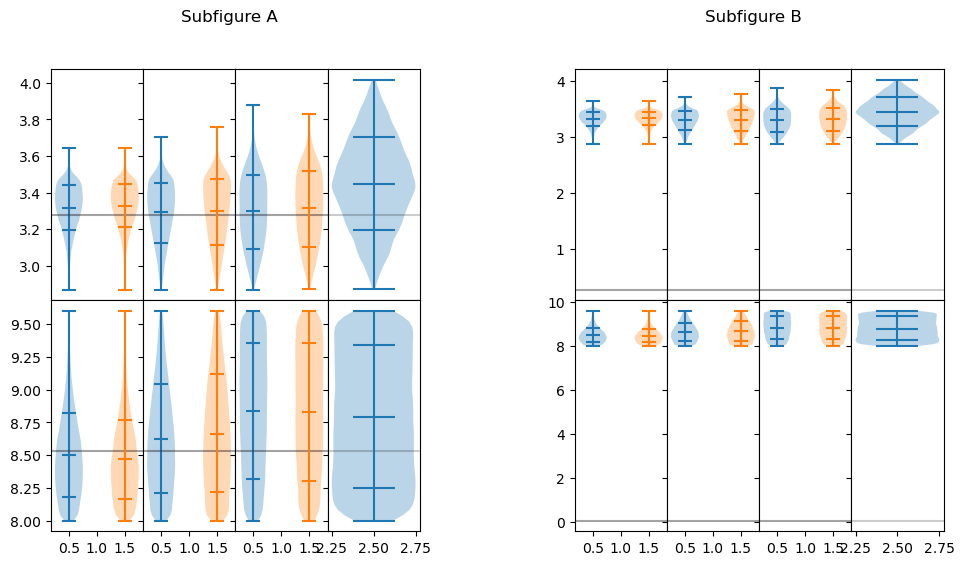

In [120]:
fig = plt.figure(figsize=(10, 6))

# Create 2 subfigures side by side
subfigs = fig.subfigures(1, 2, wspace=0.1)

# Left subfigure: 2 rows x 2 columns = 4 axes
axs_left = subfigs[0].subplots(2, 4, sharex='col', sharey='row')
subfigs[0].subplots_adjust(wspace=0, hspace=0)
subfigs[0].suptitle('Subfigure A')

# Right subfigure: also 2x2
axs_right = subfigs[1].subplots(2, 4, sharex='col', sharey='row')
subfigs[1].subplots_adjust(wspace=0)
subfigs[1].suptitle('Subfigure B')

axes = [axs_left, axs_right]

for run_i, survey_chains in enumerate(chains_runs[0]):
    print(f"run_i={run_i}")
    for survey_i, chain in enumerate(survey_chains[2:]):
        print(f"survey_i={survey_i}")
        
        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin
        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())
  
        for ip, p in enumerate(true_params[2:]):
            ax = axs_left
            if ip > 1:
                ax = axs_right
                ip = ip - 2

            ax[ip,run_i].axhline(p, alpha=.2, color='black')
            ax[ip,run_i].violinplot(chain[:,ip], [survey_i+.5], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            if ip == len(true_params[2:]) -1:
                ax[ip,0].set_ylabel(rf"$\tau_{{\mathrm{{CMB}}}}$", fontsize=16)
            # else:
            #     ax[ip,0].set_ylabel(astro_pnames_formatted[2+ip], fontsize=16)

chain = make_tauchains(s, A=True, dropA=True, truths=df.loc[config.sn].to_dict())
for ip, p in enumerate(true_params[2:]):
    ax = axs_left
#    ax[ip,0].set_ylabel(astro_pnames_formatted[2+ip], fontsize=16)
    if ip > 1:  
        ax = axs_right
        ip = ip - 2

    ax[ip,run_i+1].axhline(p, alpha=.2, color='black')
    ax[ip,run_i+1].violinplot(chain[:,ip], [survey_i+ 1 +.5], points=40, widths=0.5,
                showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                bw_method='silverman')
    if ip == len(true_params[2:]) -1:
        ax[ip,0].set_ylabel(rf"$\tau_{{\mathrm{{CMB}}}}$", fontsize=16)

#     ax[3,run_i].set_xticks(np.arange(1, len(setups[2:])+.5))
#     ax[3,i].set_xticklabels([f"{setup}" for si, setup in enumerate(setups[2:])])

#     ax[0,run_i].set_title(f'{survey_labels[run_i]}', fontsize=12)

#     #ax[0,run_i].set_title(f'priors', fontsize=12)

#     fig.savefig('violins.png', bbox_inches='tight', pad_inches=0.05, dpi=300)


In [169]:
s, l = utils.load_samples(f"{base_dir}/inference/productionruns3_mechaemu_10emus/CMB-HD/noiseless/")

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_10emus/CMB-HD/noiseless/...


In [172]:
(np.mean(s,axis=0) - true_params[2:]) / np.std(s, axis=0)

array([ 0.34559126, -0.09908729, -0.97592757, 54.2927727 ])

In [51]:
import pandas as pd

dim_labels = [*df.columns[2:], 'tau_CMB']

rundirs = ['productionruns2_mechaemu',
                            'productionruns3_mechaemu_fiducialtau', 
                            'productionruns3_mechaemu_simu10818']
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

rows = []
#chains_runs = []
pnames = [*df.columns[2:], 'A', 'tau_CMB']
for idir, rundir in enumerate(rundirs):
    print(rundir)
   # chains_surveys = []
    for isur, survey in enumerate(survey_labels):
     #   chains = []
        for iset, setup in enumerate(setups):
            path = f"{base_dir}/inference/{rundir}/{survey}/{setup}"
            if os.path.exists(f"{path}/saved_chains.h5"):
                print(f"On run {rundir}, survey {survey}, with setup {setup}")
                samples = chains_runs[idir][isur][iset]
                samples = make_tauchains(samples, A=True, dropA=False, truths=df.loc[config.sn].to_dict())
                for i in range(samples.shape[0]):  # iterate over rows (samples)
                    for dim_idx in range(samples.shape[1]):  # iterate over columns
                        # print(f"samples shape is {samples[i, dim_idx].shape}")
                        # print(f"i = {i}, dim_idx = {dim_idx}")
                        rows.append({
                            "value": samples[i, dim_idx],
                            "parameter": pnames[dim_idx],
                            "rundir": rundir,
                            "survey": survey,
                            "setup": setup,
                            "sample_index": i  # optional
                        })

for i_setup, setup in enumerate(['CMB-HD']):
    samples, l = utils.load_samples(f"{base_dir}/inference/productionruns_justpriors/{setup}")
    samples = make_tauchains(samples, A=True, dropA=False, truths=df.loc[config.sn].to_dict())
    for i in range(samples.shape[0]):  # iterate over rows (samples)
        for dim_idx in range(samples.shape[1]):  # iterate over columns
            # print(f"samples shape is {samples[i, dim_idx].shape}")
            # print(f"i = {i}, dim_idx = {dim_idx}")
            rows.append({
                "value": samples[i, dim_idx],
                "parameter": pnames[dim_idx],
                "rundir": rundirs[0],
                "survey": 'CMB-HD',
                "setup": setup + "_priors",
                "sample_index": i  # optional
            })

df_samples = pd.DataFrame(rows)

productionruns2_mechaemu
On run productionruns2_mechaemu, survey CMB-HD, with setup noiseless


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


On run productionruns2_mechaemu, survey CMB-HD, with setup noiseless_Planck
On run productionruns2_mechaemu, survey CMB-HD, with setup addnoise
On run productionruns2_mechaemu, survey CMB-HD, with setup addnoise_Planck
On run productionruns2_mechaemu, survey CMB-S4, with setup noiseless
On run productionruns2_mechaemu, survey CMB-S4, with setup noiseless_Planck
On run productionruns2_mechaemu, survey CMB-S4, with setup addnoise
On run productionruns2_mechaemu, survey CMB-S4, with setup addnoise_Planck
On run productionruns2_mechaemu, survey SO-LAT, with setup noiseless
On run productionruns2_mechaemu, survey SO-LAT, with setup noiseless_Planck
On run productionruns2_mechaemu, survey SO-LAT, with setup addnoise
On run productionruns2_mechaemu, survey SO-LAT, with setup addnoise_Planck
productionruns3_mechaemu_fiducialtau
On run productionruns3_mechaemu_fiducialtau, survey CMB-HD, with setup noiseless
On run productionruns3_mechaemu_fiducialtau, survey CMB-HD, with setup noiseless_Planck

In [53]:
df_samples[df_samples['setup'] == 'CMB-HD_priors']

,value,parameter,rundir,survey,setup,sample_index
15234000,3.891974,tau,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,0
15234001,8.048890,Mmin,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,0
15234002,0.377278,fesc,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,0
15234003,0.994858,A,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,0
15234004,0.043593,tau_CMB,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,0
...,...,...,...,...,...,...
15353995,3.356403,tau,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,23999
15353996,8.811454,Mmin,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,23999
15353997,0.114871,fesc,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,23999
15353998,0.963007,A,productionruns2_mechaemu,CMB-HD,CMB-HD_priors,23999


<ErrorbarContainer object of 3 artists>

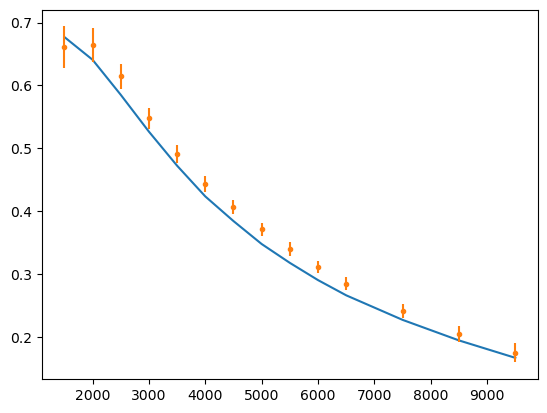

In [41]:
data = np.load(f'{base_dir}/inference/productionruns2_mechaemu/CMB-HD/noiseless/data.npz', allow_pickle=True)

plt.plot(data['ells'], data['model'])
plt.errorbar(data['ells'], data['datapoints'], yerr=data['err'], marker='.', ls='')

In [58]:
samples[0][3]

np.float64(0.9948584353170218)

0, CMB-HD
0, CMB-HD
0, CMB-HD
0, CMB-HD
1, CMB-S4
1, CMB-S4
1, CMB-S4
1, CMB-S4
2, SO-LAT
2, SO-LAT
2, SO-LAT
2, SO-LAT
2, SO-LAT
2, SO-LAT
2, SO-LAT
2, SO-LAT


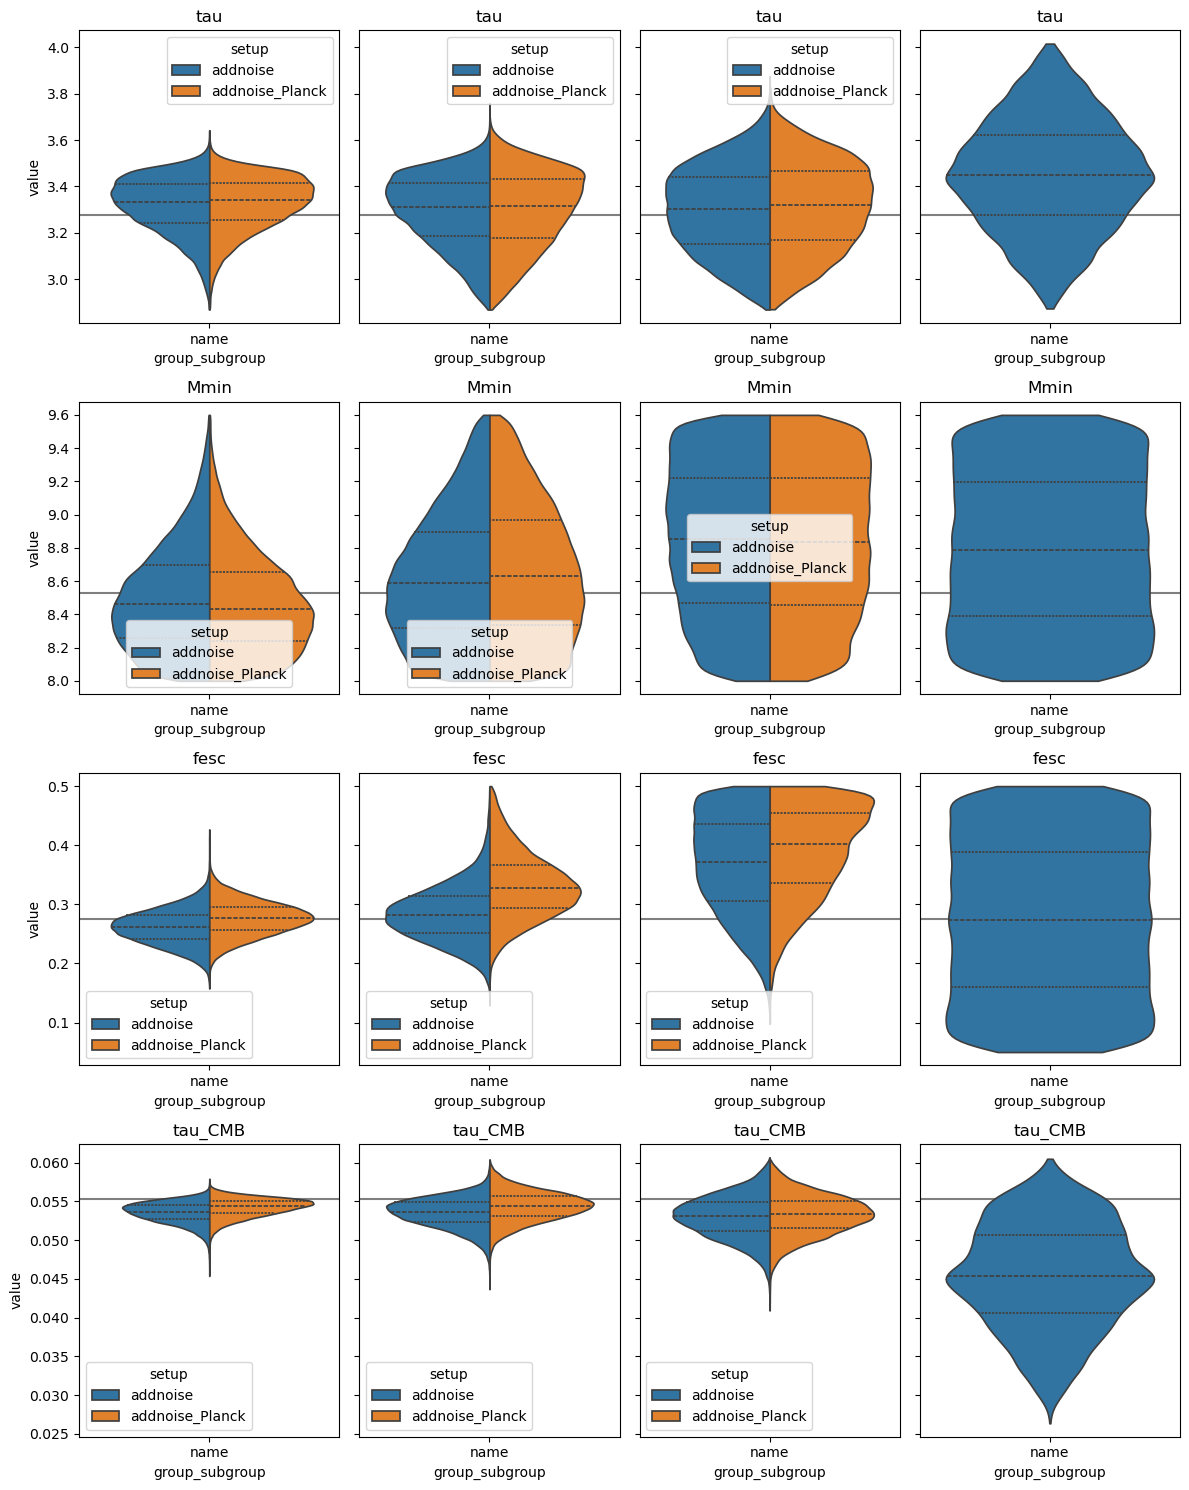

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(4, 4, figsize=(12, 15), sharex=False, sharey='row')
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i_survey, survey in enumerate(survey_labels):
    for i_param, param in enumerate(dim_labels):
        print(f"{i_survey}, {survey}")
        # print(f"{i_param}, {param}")

        ax = axs[i_param, i_survey]
        ax.axhline(true_params[2+i_param], color='black', alpha=.5, zorder=0)
        # Filter to only the two main groups
        df_subset = df_samples[
            (df_samples["parameter"] == param) &
            (df_samples["rundir"] == 'productionruns2_mechaemu') &
            (df_samples["survey"] == survey) &
            # (df_samples["setup"] == 'noiseless')
           (df_samples["setup"].isin(setups[2:]))
        ].copy()
    
        # Create a new column for combined group/subgroup label
        df_subset["group_subgroup"] = 'name' #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
        
        # Plot each group_subgroup as a separate category on the x-axis
        sns.violinplot(data=df_subset, split=True, common_norm=True, cut=0,
                       inner='quart', hue="setup", x="group_subgroup", y="value", ax=ax)
        ax.set_title(param)

for i_param, param in enumerate(dim_labels):
    print(f"{i_survey}, {survey}")
    # print(f"{i_param}, {param}")

    ax = axs[i_param, i_survey+1]
    ax.axhline(true_params[2+i_param], color='black', alpha=.5, zorder=0)
    # Filter to only the two main groups
    df_subset = df_samples[
        (df_samples["parameter"] == param) &
        (df_samples["rundir"] == 'productionruns2_mechaemu') &
        (df_samples["survey"] == 'CMB-HD') &
        # (df_samples["setup"] == 'noiseless')
       (df_samples["setup"] == 'CMB-HD_priors')
    ].copy()

    # Create a new column for combined group/subgroup label
    df_subset["group_subgroup"] = 'name' #df_subset["rundir"] + "_" + df_subset["parameter"].astype(str) + "_" + df_subset["survey"].astype(str)
    
    # Plot each group_subgroup as a separate category on the x-axis
    sns.violinplot(data=df_subset, split=False, common_norm=True, cut=0,
                   inner='quart', x="group_subgroup", y="value", ax=ax)
    ax.set_title(param)

plt.tight_layout()
plt.show()


In [46]:
df_subset

,value,parameter,rundir,survey,setup,sample_index,group_subgroup


array([0.04359281, 0.05337768, 0.03270758, ..., 0.03909752, 0.03866439,
       0.04055832], shape=(24000,))

In [191]:
df0 = df_samples[df_samples['rundir'] == df_samples['rundir'].unique()[0]]
df1 = df0[df0['survey'] == 'CMB-HD']
df2 = df1[df1['setup'] == 'noiseless']
df2

,value,parameter,rundir,survey,setup,sample_index
0,3.891974,tau,productionruns2_mechaemu,CMB-HD,noiseless,0
1,8.048890,Mmin,productionruns2_mechaemu,CMB-HD,noiseless,0
2,0.377278,fesc,productionruns2_mechaemu,CMB-HD,noiseless,0
3,0.043593,A,productionruns2_mechaemu,CMB-HD,noiseless,0
4,0.043593,tau_CMB,productionruns2_mechaemu,CMB-HD,noiseless,0
...,...,...,...,...,...,...
119995,3.356403,tau,productionruns2_mechaemu,CMB-HD,noiseless,23999
119996,8.811454,Mmin,productionruns2_mechaemu,CMB-HD,noiseless,23999
119997,0.114871,fesc,productionruns2_mechaemu,CMB-HD,noiseless,23999
119998,0.040558,A,productionruns2_mechaemu,CMB-HD,noiseless,23999


In [192]:
s.shape

(120000, 4)

In [ ]:
fig, ax = plt.subplots(4, len(survey_labels), sharex=True, sharey='row', figsize=(5,12))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

for run_i, survey_chains in enumerate(chains_runs[0]):
    print(len(survey_chains))
    print(f"run_i={run_i}")
    for survey_i, chain in enumerate(survey_chains[2:]):
        print(f"survey_i={survey_i}")
    # lp = lps[n]
    # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin
    
        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True
    
        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())
    
        for ip, p in enumerate(true_params[2:]):
            ax[ip,run_i].axhline(p, alpha=.2, color='black')
            ax[ip,run_i].violinplot(chain[:,ip], [survey_i+.5], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            if ip == len(true_params[2:]) -1:
                ax[ip,0].set_ylabel(rf"$\tau_{{\mathrm{{CMB}}}}$", fontsize=16)
            else:
                ax[ip,0].set_ylabel(astro_pnames_formatted[2+ip], fontsize=16)
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,run_i].set_xticks(np.arange(1, len(setups[2:])+.5))
    ax[3,i].set_xticklabels([f"{setup}" for si, setup in enumerate(setups[2:])])
        
    ax[0,run_i].set_title(f'{survey_labels[run_i]}', fontsize=12)

    fig.savefig('violins.png', bbox_inches='tight', pad_inches=0.05, dpi=300)


In [20]:
survey_colors = ['#2ff3e0', '#cbfbf8', '#f8d210', '#fdf4aa', '#fa26a0', '#fdb9d8']

0
1
2
3
4
5


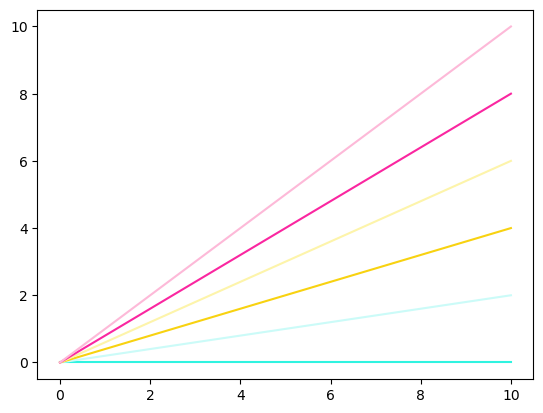

In [21]:
x = np.linspace(0,10)

for i, col in enumerate(survey_colors):
    print(i)
    plt.plot(x, i * .2 * x, color=col)

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


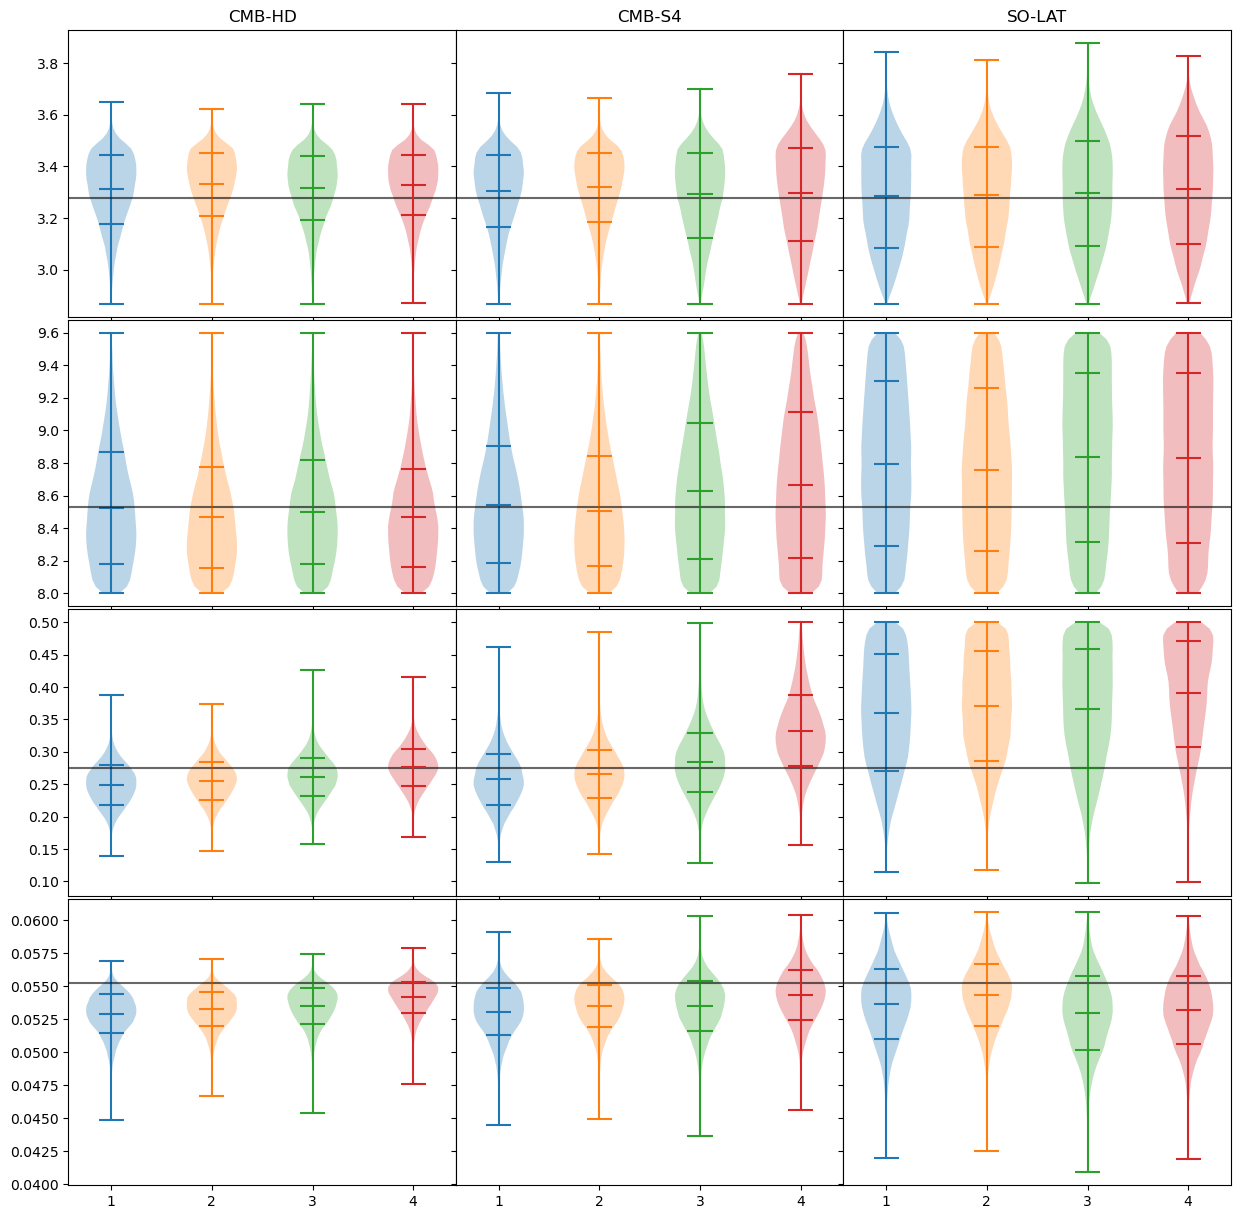

In [82]:
fig, ax = plt.subplots(4, len(survey_labels), sharex=True, sharey='row', figsize=(15,15))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

chains_all = chains_runs[0]
for i, chains in enumerate(chains_all):
    for j, chain in enumerate(chains):
        # lp = lps[n]
        # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin

        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True

        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())

        for ip, p in enumerate(true_params[2:]):
            ax[ip,i].axhline(p, alpha=.2, color='black')
            ax[ip,i].violinplot(chain[:,ip], [j+1], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,i].set_xticks(np.arange(1, len(setups)+1))
    # ax[3,i].set_xticklabels([f"{survey} {setup}" for si, setup in enumerate(setups)])
        
    ax[0,i].set_title(f'{survey_labels[i]}', fontsize=12)


In [34]:
def plot_corner(samples, axes, label=None, **kwargs):
    x, y, z, t = samples.T

    sns.kdeplot(x=x, y=y, levels=3,
            ax=ax[1,0], **kwargs)
    sns.kdeplot(x=y, y=z, levels=3,
                ax=ax[2,1], **kwargs)
    sns.kdeplot(x=x, y=z, levels=3,
                ax=ax[2,0], **kwargs)

    sns.kdeplot(x=x, ax=ax[0,0], label=label, **kwargs)
    sns.kdeplot(x=y, ax=ax[1,1], **kwargs)
    sns.kdeplot(x=z, ax=ax[2,2], **kwargs)

    return axes

In [40]:
len(chains_runs[-1])

3

In [51]:
for i, label in enumerate(survey_labels):
    chains = chains_all[i]
    # lps = lps_all[i]
    # datas = datas_all[i]
    # nruns = len(chains)
    for n, setup in enumerate(setups[2:]):

'productionruns3_mechaemu_simu10818'

In [29]:
len(chains_runs[0][0])

4

In [32]:
for i, chains in enumerate(chains_runs[0]):
    for j, chain in enumerate(chains[2:]):
        print(2*i+j)

0
1
2
3
4
5


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)
(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


...

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(19200, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


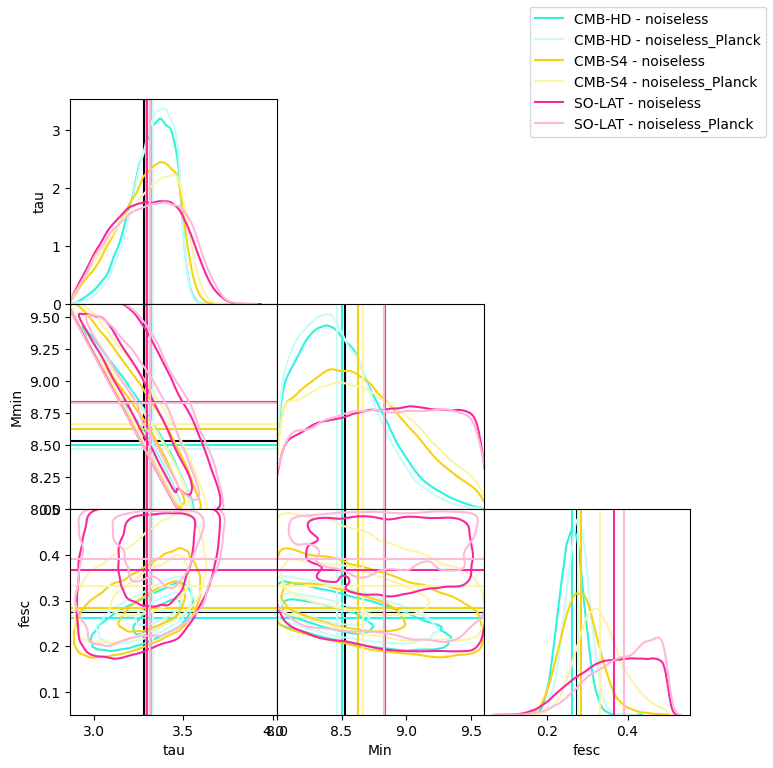

In [35]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(8,8))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

line_kwargs = {}

line_kwargs['color'] = 'black'

sn = config.sn
true_params = [*df.loc[sn].to_numpy(), *whatthetau(df.loc[sn].to_numpy())]
plot_vlines(true_params[2:], ax, **line_kwargs)

for i, chains in enumerate(chains_runs[0]):
    for j, chain in enumerate(chains[2:]):
        print(chain.shape)
        line_kwargs['color'] = survey_colors[2*i+j]
        samples = make_tauchains(chain, truths=df.loc[sn].to_dict())
        plot_corner(samples, ax, label=f'{survey_labels[i]} - {setups[j]}', **line_kwargs)
        plot_vlines(np.mean(samples, axis=0), ax, **line_kwargs)

for i in range(3):
    for j in range(3):
        axes = ax[i,j]
        if j > i:
            axes.axis('off')

        if j == 0:
            axes.set_ylabel(f'{df.columns[2+i]}')

        if j != 0:
            axes.set_ylabel('')

        if i == j:
            if j != 0:
                axes.set_ylabel('')
                axes.tick_params(axis='y', left=False, labelleft=False)
        

ax[2,1].tick_params(axis='y', left=False, labelleft=False)

ax[1,0].set_xlim(*priors[2])
ax[1,0].set_ylim(*priors[3])

ax[2,0].set_xlim(*priors[2])
ax[2,0].set_xlabel('tau')
ax[2,0].set_ylim(*priors[4])

ax[2,1].set_xlim(*priors[3])
ax[2,1].set_xlabel('Min')
ax[2,1].set_ylim(*priors[4])

ax[2,2].set_xlabel('fesc')
#[ax[2,0].set_xlim(*priors[2+i]) for i in range(1,3)]

fig.legend()

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)
(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(120000, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


(19200, 4)


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


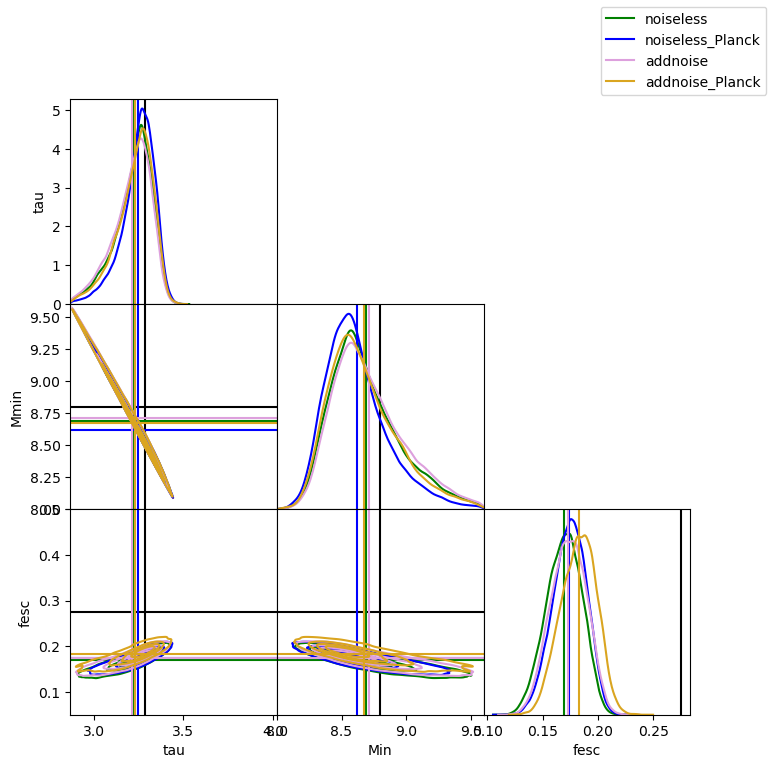

In [53]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(8,8))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

line_kwargs = {}

line_kwargs['color'] = 'black'

sn = '10818'
true_params = [*df.loc[sn].to_numpy(), *whatthetau(df.loc[sn].to_numpy())]
plot_vlines(true_params[2:], ax, **line_kwargs)

for i, chain in enumerate(chains_runs[-1][0]):
    print(chain.shape)
    line_kwargs['color'] = colors[i]
    samples = make_tauchains(chain, truths=df.loc[sn].to_dict())
    plot_corner(samples, ax, label=f'{setups[i]}', **line_kwargs)
    plot_vlines(np.mean(samples, axis=0), ax, **line_kwargs)

for i in range(3):
    for j in range(3):
        axes = ax[i,j]
        if j > i:
            axes.axis('off')

        if j == 0:
            axes.set_ylabel(f'{df.columns[2+i]}')

        if j != 0:
            axes.set_ylabel('')

        if i == j:
            if j != 0:
                axes.set_ylabel('')
                axes.tick_params(axis='y', left=False, labelleft=False)
        

ax[2,1].tick_params(axis='y', left=False, labelleft=False)

ax[1,0].set_xlim(*priors[2])
ax[1,0].set_ylim(*priors[3])

ax[2,0].set_xlim(*priors[2])
ax[2,0].set_xlabel('tau')
ax[2,0].set_ylim(*priors[4])

ax[2,1].set_xlim(*priors[3])
ax[2,1].set_xlabel('Min')
ax[2,1].set_ylim(*priors[4])

ax[2,2].set_xlabel('fesc')
#[ax[2,0].set_xlim(*priors[2+i]) for i in range(1,3)]

fig.legend()

In [ ]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(8,8))
fig.subplots_adjust(wspace=0.0, hspace=0.0)


plot_vlines(true_params[2:], ax, color='black')

sns.kdeplot(x=s[:,0], y=s[:,1], levels=5,
             color='grey', ax=ax[1,0], ls='-')
sns.kdeplot(x=s[:,1], y=s[:,2], levels=5,
             color='grey', ax=ax[2,1], ls='--')
sns.kdeplot(x=s[:,0], y=s[:,2], levels=5,
             color='grey', ax=ax[2,0], ls='--')

sns.kdeplot(x=s[:,0], ax=ax[0,0], ls='-', color='gray', label='previous run')
sns.kdeplot(x=s[:,1], ax=ax[1,1], ls='-', color='gray')
sns.kdeplot(x=s[:,2], ax=ax[2,2], ls='-', color='gray')

sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], y=samples_tau_Mmin_fesc[:,1], levels=5,
             color=colors[4], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,1], y=samples_tau_Mmin_fesc[:,2], levels=5,
             color=colors[4], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], y=samples_tau_Mmin_fesc[:,2], levels=5,
             color=colors[4], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_prior[:,0], y=samples_prior[:,1], levels=5,
             color='black', ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_prior[:,1], y=samples_prior[:,2], levels=5,
             color='black', ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_prior[:,0], y=samples_prior[:,2], levels=5,
             color='black', ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_prior[:,0], ax=ax[0,0], ls='-', color='black', label=f'3 param prior')
sns.kdeplot(x=samples_prior[:,1], ax=ax[1,1], ls='-', color='black')
sns.kdeplot(x=samples_prior[:,2], ax=ax[2,2], ls='-', color='black')

sns.kdeplot(x=samples_tau_Mmin_fesc[:,0], ax=ax[0,0], ls='-', color=colors[4], label='tau/Mmin/fesc')
sns.kdeplot(x=samples_tau_Mmin_fesc[:,1], ax=ax[1,1], ls='-', color=colors[4])
sns.kdeplot(x=samples_tau_Mmin_fesc[:,2], ax=ax[2,2], ls='-', color=colors[4])

sns.kdeplot(x=samples_tau_Mmin[:,0], ax=ax[0,0], color=colors[0], label='tau/Min')
sns.kdeplot(x=samples_tau_Mmin[:,1], ax=ax[1,1], color=colors[0])
sns.kdeplot(x=samples_tau_Mmin[:,0], y=samples_tau_Mmin[:,1], levels=5, ax=ax[1,0], color=colors[0])

sns.kdeplot(x=samples_Mmin_fesc[:,0], ax=ax[1,1], ls='--', color=colors[2], label='Mmin/fesc')
sns.kdeplot(x=samples_Mmin_fesc[:,1], ax=ax[2,2], ls='--', color=colors[2],)
sns.kdeplot(x=samples_Mmin_fesc[:,0], y=samples_Mmin_fesc[:,1], color=colors[2], levels=5, ax=ax[2,1], ls='--')

sns.kdeplot(x=samples_tau_fesc[:,0], ax=ax[0,0], ls='--', color=colors[3], label='tau/fesc')
sns.kdeplot(x=samples_tau_fesc[:,1], ax=ax[2,2], ls='--', color=colors[3])
sns.kdeplot(x=samples_tau_fesc[:,0], y=samples_tau_fesc[:,1], levels=5, color=colors[3], ax=ax[2,0], ls=':')

sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], y=samples_Mmin_prior_3percent[:,1], levels=5,
             color=colors[5], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,1], y=samples_Mmin_prior_3percent[:,2], levels=5,
             color=colors[5], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], y=samples_Mmin_prior_3percent[:,2], levels=5,
             color=colors[5], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_3percent[:,0], ax=ax[0,0], ls='-', color=colors[5], label=f'3% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_3percent[:,1], ax=ax[1,1], ls='-', color=colors[5])
sns.kdeplot(x=samples_Mmin_prior_3percent[:,2], ax=ax[2,2], ls='-', color=colors[5])


sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], y=samples_Mmin_prior_2percent[:,1], levels=5,
             color=colors[6], ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,1], y=samples_Mmin_prior_2percent[:,2], levels=5,
             color=colors[6], ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], y=samples_Mmin_prior_2percent[:,2], levels=5,
             color=colors[6], ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_2percent[:,0], ax=ax[0,0], ls='-', color=colors[6], label=f'2% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_2percent[:,1], ax=ax[1,1], ls='-', color=colors[6])
sns.kdeplot(x=samples_Mmin_prior_2percent[:,2], ax=ax[2,2], ls='-', color=colors[6])


sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], y=samples_Mmin_prior_1percent[:,1], levels=5,
             color='violet', ax=ax[1,0], ls='-')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,1], y=samples_Mmin_prior_1percent[:,2], levels=5,
             color='violet', ax=ax[2,1], ls='--')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], y=samples_Mmin_prior_1percent[:,2], levels=5,
             color='violet', ax=ax[2,0], ls='--')

sns.kdeplot(x=samples_Mmin_prior_1percent[:,0], ax=ax[0,0], ls='-', color='violet', label=f'1% Mmin prior')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,1], ax=ax[1,1], ls='-', color='violet')
sns.kdeplot(x=samples_Mmin_prior_1percent[:,2], ax=ax[2,2], ls='-', color='violet')

s, l = utils.load_samples(f"{base_dir}/inference/productionruns_justpriors/CMB-HD")

# sns.kdeplot(x=s[:,0], y=s[:,1], levels=5,
#              color='red', ax=ax[1,0], ls='-')
# sns.kdeplot(x=s[:,1], y=s[:,2], levels=5,
#              color='red', ax=ax[2,1], ls='--')
# sns.kdeplot(x=s[:,0], y=s[:,2], levels=5,
#              color='red', ax=ax[2,0], ls='--')

# sns.kdeplot(x=s[:,0], ax=ax[0,0], ls='-', color='red', label=f'prior previous')
# sns.kdeplot(x=s[:,1], ax=ax[1,1], ls='-', color='red')
# sns.kdeplot(x=s[:,2], ax=ax[2,2], ls='-', color='red')

for i in range(3):
    for j in range(3):
        axes = ax[i,j]
        if j > i:
            axes.axis('off')

        if j == 0:
            axes.set_ylabel(f'{df.columns[2+i]}')

        if j != 0:
            axes.set_ylabel('')

        if i == j:
            label = ''
            if i == 0:
                label = 'individual fit'
            sns.kdeplot(single_samples[i].flatten(), ax=axes, color=colors[1], zorder=0, label=label)
            if j != 0:
                axes.set_ylabel('')
                axes.tick_params(axis='y', left=False, labelleft=False)
        

ax[2,1].tick_params(axis='y', left=False, labelleft=False)

ax[1,0].set_xlim(*priors[2])
ax[1,0].set_ylim(*priors[3])

ax[2,0].set_xlim(*priors[2])
ax[2,0].set_xlabel('tau')
ax[2,0].set_ylim(*priors[4])

ax[2,1].set_xlim(*priors[3])
ax[2,1].set_xlabel('Min')
ax[2,1].set_ylim(*priors[4])

ax[2,2].set_xlabel('fesc')
#[ax[2,0].set_xlim(*priors[2+i]) for i in range(1,3)]

fig.legend()